In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\adaly\OneDrive\Documents\DMDeficientGalaxyTNG-1")
CATALOG = PROJECT_DIR / "data" / "dmdg_catalog_z0.csv"
df = pd.read_csv(CATALOG)

print(f"Total catalog objects: {len(df):,}")
resolved = df[
    (df["N_star"] >= 500) &
    (df["SubhaloFlag"] == 1) &
    (df["f_DM"].notna())
].copy()

print(f"Resolved galaxies: {len(resolved):,}")
centrals = resolved[
    resolved["IsSatellite"] == False
].copy()

satellites = resolved[
    (resolved["IsSatellite"] == True) &
    resolved[["x", "y", "z"]].notna().all(axis=1)
].copy()

nearest_distances = []

for _, central in centrals.iterrows():

    sats = satellites[
        satellites["GroupID"] == central["GroupID"]
    ]

    if len(sats) == 0:
        nearest_distances.append(np.nan)
        continue

    box_size = 205000.0  

    dx = np.abs(sats["x"].to_numpy() - central["x"])
    dy = np.abs(sats["y"].to_numpy() - central["y"])
    dz = np.abs(sats["z"].to_numpy() - central["z"])

    dx = np.minimum(dx, box_size - dx)
    dy = np.minimum(dy, box_size - dy)
    dz = np.minimum(dz, box_size - dz)

    distances = np.sqrt(dx**2 + dy**2 + dz**2)


    nearest_distances.append(np.min(distances))

centrals["NearestSatelliteDistance"] = nearest_distances


Total catalog objects: 13,922,457
Resolved galaxies: 154,638
Centrals: 93,039
DMDGS (total): 96
DMDGS (non-tidal stripping): 96
DMDGS Fraction: 0.0010318253635572179


In [7]:
h = 0.6774
centrals["M_star_Msun"] = centrals["M_star"] * 1e10 / h
centrals["R_half_star_log"] = np.log(centrals["R_half_star"])
centrals["M_star_Msun_log"] = np.log(centrals["M_star_Msun"])
non_dmdg_group_selected = centrals[centrals["f_DM"] >= 0.5]

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

X = centrals[["M_star_Msun_log"]]
y = centrals["R_half_star_log"]

for degree in [1, 2, 3]:
    
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    
    model.fit(X, y)
    y_pred = model.predict(X)
    
    print(
        f"Degree {degree}: "
        f"R² = {r2_score(y, y_pred):.4f}"
    )

Degree 1: R² = 0.4113
Degree 2: R² = 0.5981
Degree 3: R² = 0.5959


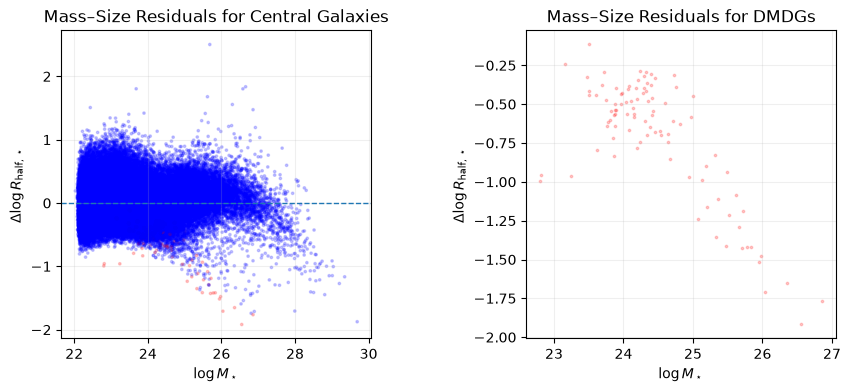

In [31]:
model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
model.fit(X, y)

centrals["R_half_star_log_residual"] = centrals["R_half_star_log"] - model.predict(centrals[["M_star_Msun_log"]])
dmdgs = centrals[
    centrals["f_DM"] < 0.5
].copy()
dmdgs_non_extreme = dmdgs[
   dmdgs["f_DM"] > 0.05
].copy()
import matplotlib.pyplot as plt
x_values = []
y_values = []
colors = []
for i, row in centrals.iterrows():
   x_values.append(row["M_star_Msun_log"])
   y_values.append(row["R_half_star_log_residual"])
   if row["f_DM"] < 0.5:
      colors.append("red") 
   else:
      colors.append("blue")
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.5) 
axs[0].scatter(
    x_values,
    y_values,
    c=colors,
    s=3,
    alpha=0.2
)

axs[0].axhline(
    0,
    linestyle="--",
    linewidth=1
)

axs[0].set_xlabel(r"$\log M_\star$")
axs[0].set_ylabel(r"$\Delta \log R_{\rm half,\star}$")
axs[0].set_title("Mass–Size Residuals for Central Galaxies")

axs[0].grid(alpha=0.2)
axs[1].scatter(
   dmdgs["M_star_Msun_log"],
   dmdgs["R_half_star_log_residual"],
   s=3,
   alpha = 0.2,
   c="red"
)
axs[1].set_xlabel(r"$\log M_\star$")
axs[1].set_ylabel(r"$\Delta \log R_{\rm half,\star}$")
axs[1].set_title("Mass–Size Residuals for DMDGs")
axs[1].grid(alpha=0.2)
plt.show()

In [32]:
import numpy as np

r = np.corrcoef(
    centrals["M_star_Msun_log"],
    centrals["R_half_star_log_residual"]
)[0, 1]

print("Residual–mass correlation:", r)
r = np.corrcoef(
    dmdgs["M_star_Msun_log"],
    dmdgs["R_half_star_log_residual"]
)[0, 1]

print("Residual–mass correlation (DMDGs):", r)

Residual–mass correlation: 1.3085183495460028e-13
Residual–mass correlation (DMDGs): -0.763873198658375


In [33]:
poly_step = model.named_steps["polynomialfeatures"]
lr_step = model.named_steps["linearregression"]
intercept = lr_step.intercept_
coefs = lr_step.coef_
beta_1 = coefs[1]
beta_2 = coefs[2]

equation = f"log R_half_star = {intercept:.4f} + ({beta_1:+.4f}) * log M_star + ({beta_2:+.4f}) * (log M_star)^2"
print("Regression Equation:")
print(equation)


Regression Equation:
log R_half_star = 66.8553 + (-5.7237) * log M_star + (+0.1246) * (log M_star)^2


In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

X = dmdgs[["M_star_Msun_log"]]
y = dmdgs["R_half_star_log_residual"]

for degree in [1, 2, 3]:
    
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    
    model.fit(X, y)
    y_pred = model.predict(X)
    
    print(
        f"Degree {degree}: "
        f"R² = {r2_score(y, y_pred):.4f}"
    )

Degree 1: R² = 0.5835
Degree 2: R² = 0.7660
Degree 3: R² = 0.7605


In [35]:
model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)
model.fit(X, y)
equation = f"log R_half_star = {intercept:.4f} + ({beta_1:+.4f}) * log M_star + ({beta_2:+.4f}) * (log M_star)^2"
print("Regression Equation:")
print(equation)

Regression Equation:
log R_half_star = 66.8553 + (-5.7237) * log M_star + (+0.1246) * (log M_star)^2


In [38]:
from scipy.stats import mannwhitneyu
dmdg_residuals = dmdgs["R_half_star_log_residual"].dropna()
centrals_non_dmdg = centrals[
   centrals["f_DM"] >= 0.5
].copy()
control_residuals = centrals_non_dmdg["R_half_star_log_residual"].dropna()
U, p = mannwhitneyu(
    dmdg_residuals,
    control_residuals,
    alternative="two-sided"
)

print("DMDG sample size:", len(dmdg_residuals))
print("Control sample size:", len(control_residuals))
print("Mann–Whitney U:", U)
print("p-value:", p)

print("\nMedian DMDG residual:", dmdg_residuals.median())
print("Median control residual:", control_residuals.median())

DMDG sample size: 96
Control sample size: 92943
Mann–Whitney U: 285800.0
p-value: 9.425867067620882e-57

Median DMDG residual: -0.5821503723040424
Median control residual: -0.018929117374668403


In [39]:
from scipy.stats import spearmanr
dmdg_data = dmdgs[
    ["M_star_Msun_log", "R_half_star_log_residual"]
].dropna()
rho, p_value = spearmanr(
    dmdg_data["M_star_Msun_log"],
    dmdg_data["R_half_star_log_residual"]
)
print("Spearman rho:", rho)
print("p-value:", p_value)
print("N:", len(dmdg_data))

Spearman rho: -0.5497965274009766
p-value: 6.565303006542687e-09
N: 96
